In [1]:
# --- import ---
import os
import sys
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils.data_loader import ButterflyDataset
from src.baseline.train import train_model
from src.baseline.evaluate import ClassificationEvaluator, LearningCurveTracker
from src.utils.save_exp import save_experiment
from src.baseline.model import BaselineCNN
from src.config import TARGET_CLASSES
from src.utils.dataset_join import join_datasets

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

NameError: name 'random' is not defined

In [ ]:
SEEDS = [42, 100, 2024, 777, 999]

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {DEVICE}.")

# 0. Baseline (with raw dataset)

In [2]:
# --- data load and prep ---
BATCH_SIZE = 32
IMAGE_SIZE = 64


data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

path = "../data/raw"
img_dir = os.path.join(path, 'train')

full_train_df = pd.read_csv('splits/full_train_split.csv')
train_df = pd.read_csv('splits/train_split.csv')
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')

train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

full_train_dataset = ButterflyDataset(df=full_train_df, img_dir=img_dir, transform=data_transform)
full_train_dataloader = data.DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = sorted(test_df['label'].unique().tolist())
C = len(class_names)

Working on cuda.


In [3]:
# --- train or load model ---

train = 1

output_dir = '../src/baseline/saved'
output_path = os.path.join(output_dir, 'raw_weights.pth')

if train:
    epochs = 50

    config = {
        "augmentation": "none",
        "batch_size": BATCH_SIZE,
        "epochs": epochs,
    }
    
    model_raw, history_raw = train_model(   
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        epochs=epochs,
        device=DEVICE,
        n_classes=C
    )

    torch.save(model_raw.state_dict(), output_path)
    save_path = save_experiment(model_raw, history_raw, config, "../src/baseline/saved")

else:
    model_raw = BaselineCNN(num_classes=C)
    if not os.path.exists(output_path):
        raise FileNotFoundError(f"No model found on {output_path}.")
    model_raw.load_state_dict(torch.load(output_path, map_location=DEVICE))
    model_raw = model_raw.to(DEVICE)
    model_raw.eval()

    history_path = os.path.join(output_dir, 'run_20260530_023037/training_history.csv')
    history_raw = pd.read_csv(history_path)
    history_raw = history_raw.to_dict(orient='list')


Epoch 1/50 -> Train Loss: 4.2071 | Train Acc: 0.0259 || Val Loss: 3.9579 | Val Acc: 0.0400
Epoch 2/50 -> Train Loss: 3.9272 | Train Acc: 0.0449 || Val Loss: 3.7636 | Val Acc: 0.0430
Epoch 3/50 -> Train Loss: 3.7402 | Train Acc: 0.0481 || Val Loss: 3.8055 | Val Acc: 0.0420
Epoch 4/50 -> Train Loss: 3.6303 | Train Acc: 0.0668 || Val Loss: 3.4712 | Val Acc: 0.0641
Epoch 5/50 -> Train Loss: 3.5480 | Train Acc: 0.0741 || Val Loss: 3.5136 | Val Acc: 0.0731
Epoch 6/50 -> Train Loss: 3.5276 | Train Acc: 0.0892 || Val Loss: 3.5747 | Val Acc: 0.0821
Epoch 7/50 -> Train Loss: 3.3866 | Train Acc: 0.1066 || Val Loss: 3.2832 | Val Acc: 0.1151
Epoch 8/50 -> Train Loss: 3.3265 | Train Acc: 0.1139 || Val Loss: 3.1503 | Val Acc: 0.1471
Epoch 9/50 -> Train Loss: 3.2127 | Train Acc: 0.1187 || Val Loss: 3.0004 | Val Acc: 0.1351
Epoch 10/50 -> Train Loss: 3.1100 | Train Acc: 0.1354 || Val Loss: 3.0931 | Val Acc: 0.1652
Epoch 11/50 -> Train Loss: 3.0855 | Train Acc: 0.1399 || Val Loss: 2.8272 | Val Acc: 0.21

Best epoch: {'epoch': 23, 'val_loss': 2.1395950023834414, 'train_loss': 2.4299069929726516, 'train_acc': 0.2718354430379747, 'val_acc': 0.35835835835835833}


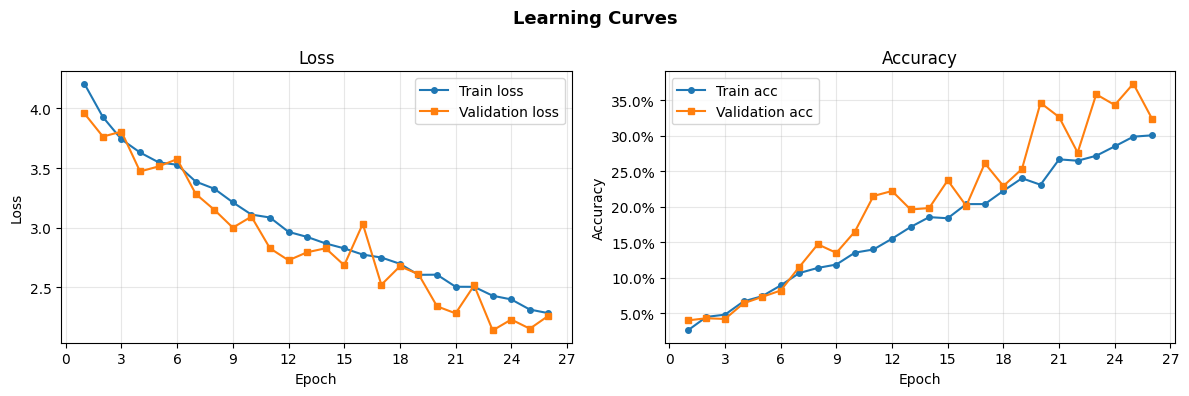

In [10]:
# --- Learning curves ---
tracker = LearningCurveTracker()
for epoch in range(len(history_raw['train_loss'])):
    tracker.update(
        train_loss = history_raw['train_loss'][epoch],
        train_acc  = history_raw['train_acc'][epoch],
        val_loss   = history_raw['val_loss'][epoch],
        val_acc    = history_raw['val_acc'][epoch],
    )
print("Best epoch:", tracker.best_epoch("val_loss"))

curves_path = os.path.join(save_path, 'learning_curves.png')
tracker.plot(save_path=curves_path)

In [7]:
# --- test ---
model_raw.eval()
all_preds = []
all_trues = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(DEVICE)
        outputs = model_raw(images)
        _, preds = torch.max(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(labels.cpu().numpy())

y_true = np.array(all_trues)
y_pred = np.array(all_preds)


Class                         Precision      Recall          F1     Support
---------------------------------------------------------------------------
ADONIS                           0.7857      0.7857      0.7857          14
AFRICAN GIANT SWALLOWTAIL        0.2353      0.3333      0.2759          12
AMERICAN SNOOT                   0.0000      0.0000      0.0000          12
AN 88                            0.6316      0.8571      0.7273          14
APPOLLO                          0.3500      0.5000      0.4118          14
ATALA                            0.4615      0.7500      0.5714          16
BANDED ORANGE HELICONIAN         0.6250      0.3333      0.4348          15
BANDED PEACOCK                   0.3571      0.3846      0.3704          13
BECKERS WHITE                    0.0000      0.0000      0.0000          13
BLACK HAIRSTREAK                 0.8462      0.7857      0.8148          14
BLUE MORPHO                      0.0000      0.0000      0.0000          12
BLUE SPOTTE

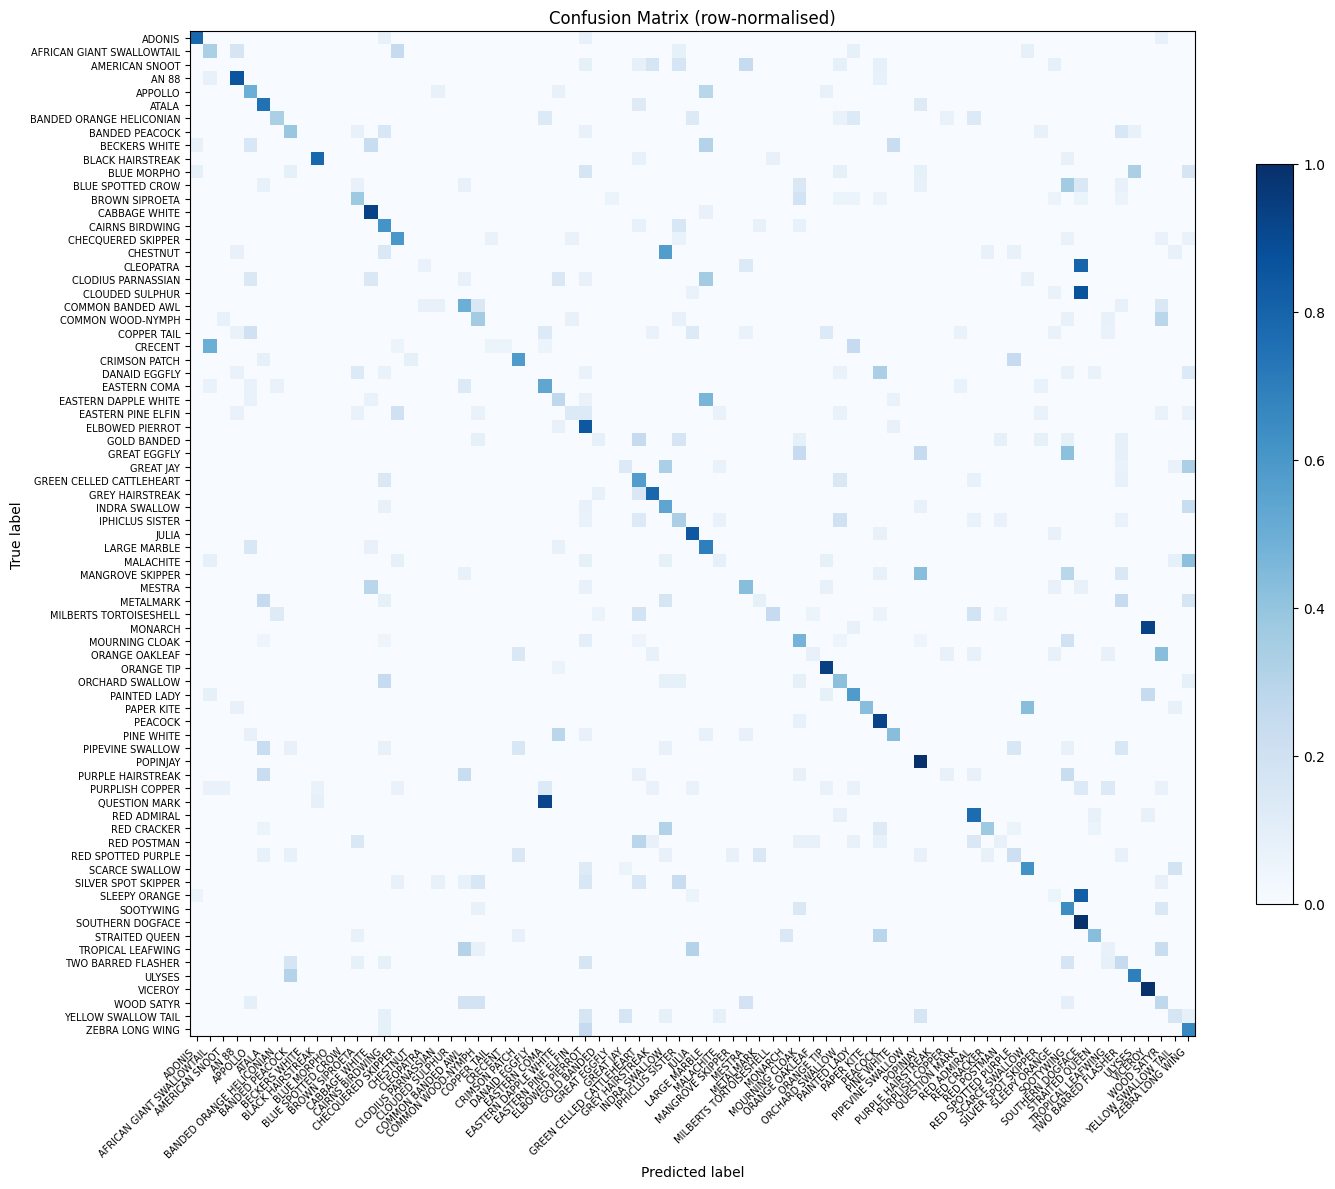

In [11]:
# --- Evaluator ---
ev_raw = ClassificationEvaluator(class_names=class_names, n_classes=C)
ev_raw.update(y_true, y_pred)
report = ev_raw.compute()
ev_raw.print_report(report)

matrix_path = os.path.join(save_path, 'confusion_matrix.png')
ev_raw.plot_confusion_matrix(report, save_path=matrix_path)

report_path = os.path.join(save_path, 'classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(str(report))

# 1.1 cVAE

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

img_dir_reais = "../data/raw/train"
cvae_augmented_dir = '../data/augmented/cvae'
caminho_novo_csv = join_datasets(base_augmented_dir=cvae_augmented_dir)

val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')
train_augmented_df = pd.read_csv(caminho_novo_csv)

train_dataset = ButterflyDataset(df=train_augmented_df, img_dir=img_dir_reais, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir_reais, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir_reais, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = sorted(test_df['label'].unique().tolist())
C = len(class_names)

In [ ]:

base_output_dir = '../src/baseline/saved_augmented_cvae'
os.makedirs(base_output_dir, exist_ok=True)

epochs = 100

macro_f1_scores = []
accuracy_scores = []

# --- INÍCIO DO LOOP DE SEEDS ---
for i, seed in enumerate(SEEDS):
    print(f"\n" + "="*50)
    print(f"EXPERIÊNCIA [Seed {seed}] ({i+1}/{len(SEEDS)})")
    print("="*50)
    
    set_seed(seed)
    
    seed_output_dir = os.path.join(base_output_dir, f"seed_{seed}")
    os.makedirs(seed_output_dir, exist_ok=True)
    weight_path = os.path.join(seed_output_dir, 'model_weights.pth')
    
    from src.baseline.model import BaselineCNN
    model_augmented = BaselineCNN(num_classes=C).to(DEVICE)
    
    config_exp = {
        "augmentation": "cvae",
        "batch_size": BATCH_SIZE,
        "epochs": epochs,
        "seed": seed
    }
    
    print(f"A treinar...")
    model_augmented, history_augmented = train_model(   
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        epochs=epochs,
        device=DEVICE,
        n_classes=C
    )
    
    torch.save(model_augmented.state_dict(), weight_path)
    
    save_path = save_experiment(model_augmented, history_augmented, config_exp, seed_output_dir)
    
    print(f"A testar...")
    model_augmented.eval()
    
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(DEVICE)
            outputs = model_augmented(images)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    ev_raw = ClassificationEvaluator(class_names=class_names, n_classes=C)
    ev_raw.update(y_true, y_pred)
    report = ev_raw.compute()
    
    if 'macro avg' in report and 'f1-score' in report['macro avg']:
        macro_f1_scores.append(report['macro avg']['f1-score'])
    if 'accuracy' in report:
        accuracy_scores.append(report['accuracy'])
        
    matrix_path = os.path.join(save_path, 'confusion_matrix.png')
    ev_raw.plot_confusion_matrix(report, save_path=matrix_path)
    
    report_path = os.path.join(save_path, 'classification_report.txt')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(str(report))
        
    print(f"Seed {seed} concluída. Resultados guardados em: {save_path}")

# --- FIM DO LOOP DE SEEDS ---

print("\n" + "="*50)
print("RESUMO FINAL DAS 5 SEEDS (DATA AUGMENTATION: CVAE)")
print("="*50)
if accuracy_scores and macro_f1_scores:
    print(f"Accuracy Média: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
    print(f"Macro F1-Score Médio: {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")
else:
    print("Loop terminado. Verifica os ficheiros individuais de cada seed para ver as métricas extraídas.")

# 1.2 betacVAE

# 2. GANs

# 3. Diffusion Models

# 4. Comparison